# Notebook 04 (Revised) — Augmentation Validation

**CMSC 190 Special Problem**  
*Classification of High-Protein and Low-Protein Corn (Zea Mays) Using NIR Spectral Data and Machine Learning Techniques*

---

This notebook validates and demonstrates the augmentation approach used in the **revised pipeline**.  
No output files are saved here — this notebook is for documentation and verification only.

## Section 1 — Imports and Setup

We import the standard scientific Python libraries used throughout this project.  
We also add the project root to the system path so we can import from the `src/` directory.  

**Why 5-Fold Cross Validation?**  
The original pipeline used a single 80/20 train-test split and augmented the training set once.  
The revised pipeline replaces this with **5-Fold Stratified Cross Validation**.  
Our 80 samples are divided into 5 folds of 16 samples each.  
In each fold, 64 samples are used for training and 16 for testing.  
Augmentation is applied **inside each fold** on the 64 training samples only — the 16 test samples are always kept as original, unmodified spectra.  
This notebook validates that the `interpolation_augment` function works correctly before it is used inside those cross-validation loops.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Allow imports from the project root (src/ directory)
sys.path.append('../..')

from src.augmentor import interpolation_augment

# Reproducibility
random_state = 42
np.random.seed(42)

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('All imports successful.')
print(f'NumPy version  : {np.__version__}')
print(f'Pandas version : {pd.__version__}')

All imports successful.
NumPy version  : 2.4.4
Pandas version : 3.0.2


## Section 2 — Load Full Dataset

We load all 80 preprocessed NIR spectra along with their binary protein labels and sample identifiers.  
**No permanent split is made here.** All 80 samples are kept intact — splitting into training and test sets happens inside the cross-validation loops in Notebooks 05 and 06.

In [2]:
X          = np.load('../../data/processed/X_preprocessed.npy')
y          = np.load('../../data/processed/y_labels.npy')
sample_ids = np.load('../../data/processed/sample_ids.npy', allow_pickle=True)

print('Dataset loaded successfully.')
print(f'X shape          : {X.shape}   (samples × wavelengths)')
print(f'y shape          : {y.shape}')
print(f'sample_ids shape : {sample_ids.shape}')

print('\nClass distribution (full dataset):')
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    label_name = 'High Protein' if label == 1 else 'Low Protein'
    print(f'  Class {int(label)} ({label_name}): {count} samples')

Dataset loaded successfully.
X shape          : (80, 700)   (samples × wavelengths)
y shape          : (80,)
sample_ids shape : (80,)

Class distribution (full dataset):
  Class 0 (Low Protein): 40 samples
  Class 1 (High Protein): 40 samples


## Section 3 — Simulate One Fold to Validate Augmentation

To demonstrate what happens inside each CV loop, we simulate the **first fold** of a 5-Fold Stratified Cross Validation.  
Out of 80 samples, 64 are allocated to training and 16 to testing.  
Stratification ensures both splits maintain the original class ratio.  

This fold simulation represents exactly what Notebooks 05 and 06 will repeat automatically across all 5 folds.  
The 16 test samples are **original, unmodified spectra** — they are never augmented under any circumstances.

In [3]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Extract only the first fold
train_idx, test_idx = next(iter(skf.split(X, y)))

X_fold_train = X[train_idx]
X_fold_test  = X[test_idx]
y_fold_train = y[train_idx]
y_fold_test  = y[test_idx]

print('Fold 1 split:')
print(f'  X_fold_train shape : {X_fold_train.shape}')
print(f'  X_fold_test  shape : {X_fold_test.shape}')
print(f'  y_fold_train shape : {y_fold_train.shape}')
print(f'  y_fold_test  shape : {y_fold_test.shape}')

print('\nClass distribution — Training fold:')
unique, counts = np.unique(y_fold_train, return_counts=True)
for label, count in zip(unique, counts):
    label_name = 'High Protein' if label == 1 else 'Low Protein'
    print(f'  Class {int(label)} ({label_name}): {count} samples')

print('\nClass distribution — Test fold:')
unique, counts = np.unique(y_fold_test, return_counts=True)
for label, count in zip(unique, counts):
    label_name = 'High Protein' if label == 1 else 'Low Protein'
    print(f'  Class {int(label)} ({label_name}): {count} samples')

Fold 1 split:
  X_fold_train shape : (64, 700)
  X_fold_test  shape : (16, 700)
  y_fold_train shape : (64,)
  y_fold_test  shape : (16,)

Class distribution — Training fold:
  Class 0 (Low Protein): 32 samples
  Class 1 (High Protein): 32 samples

Class distribution — Test fold:
  Class 0 (Low Protein): 8 samples
  Class 1 (High Protein): 8 samples


## Section 4 — Augment the Training Fold

We now apply `interpolation_augment` to the 64 training samples from Fold 1.  
This function generates synthetic spectra using **linear interpolation** between pairs of real training spectra, with a mixing weight alpha drawn uniformly from U(0.1, 0.9), following the method of Li et al. (2025).  

The 64 training samples are augmented to a total of **2,000 samples**.  
Because augmentation is applied **independently inside each fold**, there is no leakage between folds — synthetic samples from one fold's training set never contaminate another fold's test set.  
The 16 test samples are **completely untouched** throughout this process.

In [4]:
X_fold_augmented, y_fold_augmented = interpolation_augment(
    X_fold_train,
    y_fold_train,
    target_total=2000,
    random_state=42
)

print('\nAugmented training fold:')
print(f'  X_fold_augmented shape : {X_fold_augmented.shape}')
print(f'  y_fold_augmented shape : {y_fold_augmented.shape}')

print('\nClass distribution after augmentation:')
unique, counts = np.unique(y_fold_augmented, return_counts=True)
for label, count in zip(unique, counts):
    label_name = 'High Protein' if label == 1 else 'Low Protein'
    print(f'  Class {int(label)} ({label_name}): {count} samples')

Interpolation Augmentation
Original training size          : 64
Synthetic samples to generate   : 1936
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 988 samples
  1 (High Protein): 1012 samples

Augmented training fold:
  X_fold_augmented shape : (2000, 700)
  y_fold_augmented shape : (2000,)

Class distribution after augmentation:
  Class 0 (Low Protein): 988 samples
  Class 1 (High Protein): 1012 samples


## Section 5 — Visualize Original vs Augmented Spectra

The two panels below compare the original 64 training spectra (left) against a random sample of 100 augmented spectra (right).  
Spectra are colored by protein class: **red** for High Protein and **blue** for Low Protein.  

The synthetic spectra follow the same spectral shape and wavelength response as the originals, confirming that the augmentation does not introduce unrealistic spectral patterns.  
The augmented set shows greater diversity (more spread between individual curves) while remaining physically plausible.

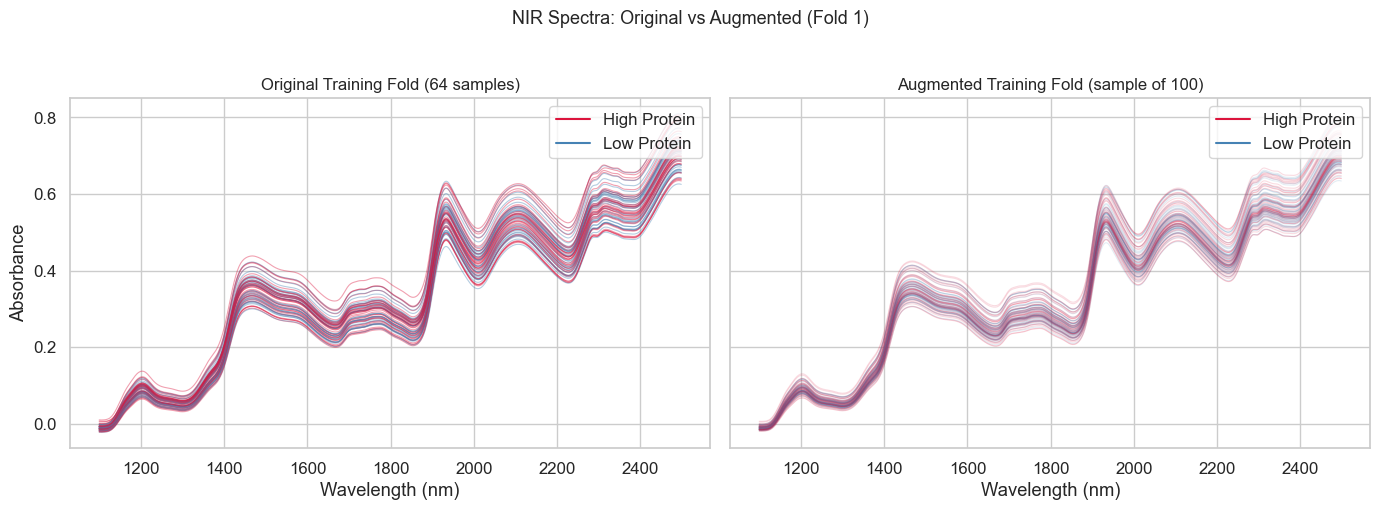

In [5]:
wavelengths = np.linspace(1100, 2498, 700)

# Sample 100 random augmented spectra for the right panel
np.random.seed(42)
sample_idx = np.random.choice(len(X_fold_augmented), size=100, replace=False)
X_aug_sample = X_fold_augmented[sample_idx]
y_aug_sample = y_fold_augmented[sample_idx]

color_map = {0: 'steelblue', 1: 'crimson'}
label_map  = {0: 'Low Protein', 1: 'High Protein'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Left panel: original 64 training spectra ---
for i in range(len(X_fold_train)):
    axes[0].plot(
        wavelengths, X_fold_train[i],
        color=color_map[int(y_fold_train[i])],
        alpha=0.4, linewidth=0.8
    )

# Add legend handles for left panel
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='crimson',   lw=1.5, label='High Protein'),
    Line2D([0], [0], color='steelblue', lw=1.5, label='Low Protein'),
]
axes[0].legend(handles=legend_handles, loc='upper right')
axes[0].set_title('Original Training Fold (64 samples)', fontsize=12)
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel('Absorbance')

# --- Right panel: 100 sampled augmented spectra ---
for i in range(len(X_aug_sample)):
    axes[1].plot(
        wavelengths, X_aug_sample[i],
        color=color_map[int(y_aug_sample[i])],
        alpha=0.15, linewidth=0.8
    )

axes[1].legend(handles=legend_handles, loc='upper right')
axes[1].set_title('Augmented Training Fold (sample of 100)', fontsize=12)
axes[1].set_xlabel('Wavelength (nm)')

plt.suptitle('NIR Spectra: Original vs Augmented (Fold 1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 6 — Visualize Class Distribution Before and After Augmentation

These bar charts compare the class balance of the original 64 training samples (left) versus the 2,000 augmented samples (right).  

The augmentation method preserves the original class proportions because synthetic samples are generated by interpolating *within* pairs of real spectra.  
When two samples from different classes are mixed, the label is determined by majority weight (rounding), which naturally maintains class balance over a large number of synthetic samples.

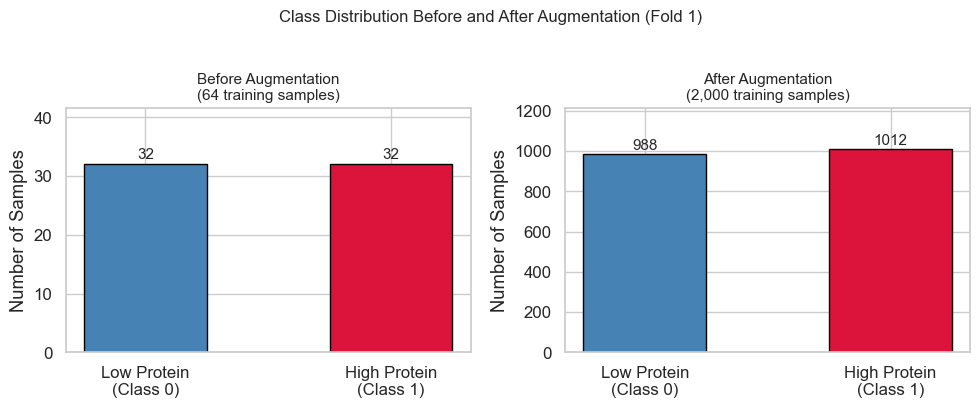

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Data for bar charts
class_labels = ['Low Protein\n(Class 0)', 'High Protein\n(Class 1)']
bar_colors   = ['steelblue', 'crimson']

# Before augmentation
orig_counts = [int(np.sum(y_fold_train == 0)), int(np.sum(y_fold_train == 1))]
axes[0].bar(class_labels, orig_counts, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('Before Augmentation\n(64 training samples)', fontsize=11)
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(orig_counts) * 1.3)
for bar, val in zip(axes[0].patches, orig_counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val), ha='center', va='bottom', fontsize=11
    )

# After augmentation
aug_counts = [int(np.sum(y_fold_augmented == 0)), int(np.sum(y_fold_augmented == 1))]
axes[1].bar(class_labels, aug_counts, color=bar_colors, edgecolor='black', width=0.5)
axes[1].set_title('After Augmentation\n(2,000 training samples)', fontsize=11)
axes[1].set_ylabel('Number of Samples')
axes[1].set_ylim(0, max(aug_counts) * 1.2)
for bar, val in zip(axes[1].patches, aug_counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val), ha='center', va='bottom', fontsize=11
    )

plt.suptitle('Class Distribution Before and After Augmentation (Fold 1)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Section 7 — Summary

This notebook validated the augmentation approach used in the revised NIR maize classification pipeline.  
Below is a summary of the key design decisions:

| Item | Detail |
|------|--------|
| **Revised approach** | 5-Fold Stratified Cross Validation |
| **Dataset size** | 80 samples total (40 High Protein, 40 Low Protein) |
| **Per-fold split** | 64 training samples / 16 test samples |
| **Augmented size** | 64 → 2,000 training samples per fold |
| **Augmentation method** | Linear interpolation, alpha ~ U(0.1, 0.9), based on Li et al. (2025) |
| **Test set treatment** | 16 test samples are **never augmented** |
| **Data leakage** | None — augmentation is applied independently inside each fold |
| **Files saved** | **None** — this notebook is for validation only |

### Next steps

The actual cross-validation loops (where augmentation is applied inside each fold at training time) are implemented in:  
- `notebooks/revised/05_plsda_svm_revised.ipynb` — PLS-DA and SVM classifiers  
- `notebooks/revised/06_1d_cnn_revised.ipynb` — 1D Convolutional Neural Network  

**Reference:**  
Li, Y., et al. (2025). SpecTran